# 🧠 Algoritmo y Código de Teoría — TODAS LAS PLANTILLAS
## Examen Final - Tema 4 (2 puntos)

Este notebook contiene **plantillas listas para los 12 algoritmos** vistos en la presentación de la Dra. Méndez. Cuando te asignen un algoritmo, ve directamente a su sección y adapta el input.

Cada plantilla cumple con la rúbrica:
1. ✅ Fundamentos matemáticos
2. ✅ Descripción formal/narrativa
3. ✅ Pseudocódigo (literal de la presentación)
4. ✅ Código Python con buenas prácticas
5. ✅ Aplicación con un input

---

## 📑 Índice

**Aprendizaje supervisado:**
1. [Regresión Lineal](#1-regresion-lineal)
2. [Regresión Logística](#2-regresion-logistica)
3. [SVM (Support Vector Machines)](#3-svm)
4. [k-Nearest Neighbors (k-NN)](#4-knn)
5. [Naive Bayes](#5-naive-bayes)
6. [Árbol de Decisión](#6-arbol-decision)
7. [Random Forest](#7-random-forest)
8. [Gradient Boosting](#8-gradient-boosting)
9. [XGBoost](#9-xgboost)

**Aprendizaje no supervisado:**
10. [K-means Clustering](#10-kmeans)
11. [DBSCAN](#11-dbscan)
12. [Hierarchical Agglomerative Clustering (HAC)](#12-hac)
13. [Isolation Forest](#13-iforest)

---

## 🔧 Setup común — ejecuta SIEMPRE primero

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, classification_report,
                              mean_squared_error, mean_absolute_error, r2_score,
                              ConfusionMatrixDisplay, silhouette_score)
from sklearn.datasets import load_iris, load_breast_cancer, load_diabetes, make_blobs

# Buena práctica: semilla fija
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ Setup listo')

✅ Setup listo


<a id='1-regresion-lineal'></a>
# 1️⃣ Regresión Lineal por Gradiente Descendiente

## 1.1 Fundamentos matemáticos

**Hipótesis:**
$$h_\theta(x) = \theta^T x$$

**Función de costo (MSE):**
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

**Regla de actualización (descenso de gradiente):**
$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$$

## 1.2 Descripción narrativa

Modelo de **aprendizaje supervisado para regresión** (predecir valores continuos). Asume que la relación entre las variables independientes y la dependiente es **lineal**. El descenso de gradiente busca iterativamente los pesos `θ` que minimizan el error cuadrático medio.

## 1.3 Pseudocódigo (literal de la presentación)

```
Algoritmo: Regresión Lineal por Gradiente Descendiente
Entrada: Matriz X, vector y, tasa de aprendizaje alpha, iteraciones T
Salida: Pesos theta

Inicializar theta en ceros o valores aleatorios
Para t desde 1 hasta T:
    Calcular predicciones: error = (X * theta) - y
    Calcular gradiente: grad = (1/m) * (X_transpuesta * error)
    Actualizar pesos: theta = theta - alpha * grad
Retornar theta
```

In [2]:
# 1.4 Implementación desde cero (siguiendo el pseudocódigo)
def regresion_lineal_gd(X, y, alpha=0.01, T=1000):
    m, n = X.shape
    theta = np.zeros(n)
    for t in range(T):
        error = X @ theta - y
        grad = (1/m) * (X.T @ error)
        theta = theta - alpha * grad
    return theta

# 1.5 Aplicación: dataset diabetes (regresión)
from sklearn.linear_model import LinearRegression

data = load_diabetes()
X = data.data
y = data.target

# Buenas prácticas: split y escalado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)

# Agregar columna de unos para el intercepto
X_train_b = np.c_[np.ones(len(X_train_esc)), X_train_esc]
X_test_b  = np.c_[np.ones(len(X_test_esc)),  X_test_esc]

# Entrenar
theta = regresion_lineal_gd(X_train_b, y_train, alpha=0.05, T=2000)
y_pred = X_test_b @ theta

# Métricas (regresión)
print('═══ Regresión Lineal (implementación propia) ═══')
print(f'MAE : {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE : {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'R²  : {r2_score(y_test, y_pred):.4f}')

# Comparar con sklearn
lr = LinearRegression().fit(X_train_esc, y_train)
print(f'\nR² sklearn: {lr.score(X_test_esc, y_test):.4f}')

═══ Regresión Lineal (implementación propia) ═══
MAE : 42.83
MSE : 2889.92
RMSE: 53.76
R²  : 0.4545

R² sklearn: 0.4526


---
<a id='2-regresion-logistica'></a>
# 2️⃣ Regresión Logística Binaria

## 2.1 Fundamentos matemáticos

**Función sigmoide:**
$$g(z) = \frac{1}{1 + e^{-z}}$$

**Hipótesis:**
$$h_\theta(x) = g(\theta^T x)$$

**Función de costo (Log-Loss):**
$$J(\theta) = -\frac{1}{m} \sum_{i=1}^m \left[ y^{(i)} \log h_\theta(x^{(i)}) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]$$

## 2.2 Descripción narrativa

A pesar de su nombre, es un algoritmo de **clasificación binaria**. Predice la **probabilidad** de que una instancia pertenezca a una clase. Aplica la sigmoide a una combinación lineal de las features para obtener un valor entre 0 y 1.

## 2.3 Pseudocódigo (literal)

```
Algoritmo: Regresión Logística Binaria
Entrada: X, y, alpha, T
Salida: theta

1. Inicializar theta
2. Para cada iteración t = 1 hasta T:
   a. z = X * theta
   b. h = 1 / (1 + exp(-z))                  # sigmoide
   c. error = h - y
   d. gradiente = (1/m) * (X_transpuesta * error)
   e. theta = theta - alpha * gradiente
3. Retornar theta
```

In [3]:
# 2.4 Implementación desde cero
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

def regresion_logistica(X, y, alpha=0.1, T=2000):
    m, n = X.shape
    theta = np.zeros(n)
    for t in range(T):
        z = X @ theta
        h = sigmoide(z)
        gradiente = (1/m) * (X.T @ (h - y))
        theta = theta - alpha * gradiente
    return theta

# 2.5 Aplicación: dataset breast cancer (clasificación binaria)
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)

# Agregar bias
X_train_b = np.c_[np.ones(len(X_train_esc)), X_train_esc]
X_test_b  = np.c_[np.ones(len(X_test_esc)),  X_test_esc]

theta = regresion_logistica(X_train_b, y_train, alpha=0.1, T=2000)
probs = sigmoide(X_test_b @ theta)
y_pred = (probs >= 0.5).astype(int)

print('═══ Regresión Logística (propia) ═══')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1       : {f1_score(y_test, y_pred):.4f}')
print(f'\nMatriz de confusión:\n{confusion_matrix(y_test, y_pred)}')

# Comparación sklearn
lr = LogisticRegression(max_iter=2000).fit(X_train_esc, y_train)
print(f'\nAccuracy sklearn: {lr.score(X_test_esc, y_test):.4f}')

═══ Regresión Logística (propia) ═══
Accuracy : 0.9649
Precision: 0.9857
Recall   : 0.9583
F1       : 0.9718

Matriz de confusión:
[[41  1]
 [ 3 69]]

Accuracy sklearn: 0.9825


---
<a id='3-svm'></a>
# 3️⃣ Support Vector Machine (SVM)

## 3.1 Fundamentos matemáticos

**Hiperplano:**
$$\omega^T x + b = 0$$

**Función de decisión:**
$$f(x) = \text{sign}(\omega^T x + b)$$

**Problema de optimización (Hard Margin):** minimizar $\frac{1}{2} \|\omega\|^2$ sujeto a:
$$y^{(i)} (\omega^T x^{(i)} + b) \geq 1$$

Equivale a maximizar el **margen** $\frac{2}{\|\omega\|}$.

**Kernels:** Lineal $K(x,z) = x \cdot z$ ; RBF $K(x,z) = \exp(-\gamma \|x-z\|^2)$.

## 3.2 Descripción narrativa

Algoritmo supervisado de clasificación que busca el **hiperplano que maximiza el margen** entre clases. Los puntos más cercanos al hiperplano son los **vectores de soporte**. Con kernels puede resolver problemas no linealmente separables al proyectar los datos a una dimensión superior.

## 3.3 Pseudocódigo (literal)

```
Algoritmo: SVM (Hard Margin / Linear)
Entrada: X, y (etiquetas -1 o 1), alpha, lambda (regularización)
Salida: w, b

1. Inicializar w = 0, b = 0
2. Para cada iteración/época:
     Para cada ejemplo x_i:
        Si y_i * (w · x_i - b) >= 1:
           # fuera del margen: solo regularización
           dw = 2 * lambda * w
           db = 0
        Sino:
           # vector de soporte / mal clasificado
           dw = 2 * lambda * w - (x_i * y_i)
           db = y_i
        w = w - alpha * dw
        b = b - alpha * db
```

In [4]:
# 3.4 Aplicación con sklearn (recomendado en lugar de implementación propia)
from sklearn.svm import SVC

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# SVM ES MUY SENSIBLE A LA ESCALA -> escalar es OBLIGATORIO
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)
svm.fit(X_train_esc, y_train)
y_pred = svm.predict(X_test_esc)

print('═══ SVM (kernel RBF) ═══')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1       : {f1_score(y_test, y_pred):.4f}')
print(f'\nVectores de soporte: {svm.n_support_}  (uno por clase)')
print(f'\n{classification_report(y_test, y_pred)}')

═══ SVM (kernel RBF) ═══
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1       : 0.9861

Vectores de soporte: [51 46]  (uno por clase)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



---
<a id='4-knn'></a>
# 4️⃣ k-Nearest Neighbors (k-NN)

## 4.1 Fundamentos matemáticos

**Distancia euclidiana:**
$$d(x, y) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}$$

**Regla de decisión** (clasificación):
$$\hat{y} = \arg\max_v \sum_{x_i \in N_k(x')} I(y_i = v)$$

donde $N_k(x')$ son los k vecinos más cercanos a $x'$ y $I(\cdot)$ es la función indicadora.

## 4.2 Descripción narrativa

Algoritmo **supervisado, no paramétrico, lazy (perezoso)**: no construye un modelo, solo memoriza los datos. Para clasificar un punto nuevo, mide la distancia a todos los puntos del entrenamiento, toma los k más cercanos y decide por **voto mayoritario**.

## 4.3 Pseudocódigo (literal)

```
Algoritmo: k-Nearest Neighbors (k-NN)
Entrada: Dataset de entrenamiento (X, y), nuevo punto x_test, parámetro k
Salida: Clase predicha para x_test

1. Para cada ejemplo (x_i, y_i) en el dataset:
   - Calcular la distancia d_i entre x_test y x_i (Euclidiana)
   - Almacenar (d_i, y_i) en una lista
2. Ordenar la lista de menor a mayor distancia
3. Seleccionar los primeros k elementos
4. Contar la frecuencia de cada etiqueta
5. Retornar la etiqueta con mayor frecuencia (voto mayoritario)
```

In [5]:
# 4.4 Implementación desde cero (didáctica)
from collections import Counter

class KNN:
    def __init__(self, k=5):
        self.k = k
    def fit(self, X, y):
        self.X_train, self.y_train = np.array(X), np.array(y)
    def _predecir_uno(self, x):
        d = np.linalg.norm(self.X_train - x, axis=1)
        idx = np.argsort(d)[:self.k]
        return Counter(self.y_train[idx]).most_common(1)[0][0]
    def predict(self, X):
        return np.array([self._predecir_uno(x) for x in np.array(X)])

# 4.5 Aplicación con escalado (CRÍTICO para K-NN)
from sklearn.neighbors import KNeighborsClassifier

data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)

knn = KNN(k=5)
knn.fit(X_train_esc, y_train)
y_pred = knn.predict(X_test_esc)

print('═══ k-NN (propia) ═══')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'F1       : {f1_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'\nMatriz de confusión:\n{confusion_matrix(y_test, y_pred)}')

# Comparación sklearn
knn_sk = KNeighborsClassifier(n_neighbors=5).fit(X_train_esc, y_train)
print(f'\nAccuracy sklearn: {knn_sk.score(X_test_esc, y_test):.4f}')

═══ k-NN (propia) ═══
Accuracy : 0.9333
Precision: 0.9444
Recall   : 0.9333
F1       : 0.9327

Matriz de confusión:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Accuracy sklearn: 0.9333


---
<a id='5-naive-bayes'></a>
# 5️⃣ Naive Bayes

## 5.1 Fundamentos matemáticos

**Teorema de Bayes:**
$$P(C \mid X) = \frac{P(X \mid C) \cdot P(C)}{P(X)}$$

**Asunción "naive" de independencia condicional:**
$$P(X \mid C) = \prod_{i=1}^n P(x_i \mid C)$$

**Regla de decisión:**
$$\hat{y} = \arg\max_C P(C) \prod_{i=1}^n P(x_i \mid C)$$

## 5.2 Descripción narrativa

Clasificador **probabilístico** basado en el **Teorema de Bayes** con la suposición *ingenua* de que las features son **condicionalmente independientes** dada la clase. Aunque la independencia raramente se cumple, en la práctica funciona muy bien especialmente para texto (filtros de spam).

## 5.3 Pseudocódigo

```
Algoritmo: Naive Bayes (Gaussiano)
Entrada: X, y
Salida: probabilidades de cada clase, predicción

Entrenamiento:
  Para cada clase C:
    Calcular P(C) = nº de ejemplos en C / total
    Para cada feature i:
      Calcular media μ_iC y desviación σ_iC sobre los ejemplos de la clase C

Predicción para x:
  Para cada clase C:
    score(C) = log P(C) + Σ_i log N(x_i | μ_iC, σ_iC)
  Devolver la clase con mayor score
```

In [6]:
# 5.4 Aplicación con sklearn
from sklearn.naive_bayes import GaussianNB

data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Naive Bayes NO requiere escalado
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

print('═══ Naive Bayes (Gaussiano) ═══')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'F1       : {f1_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'\n{classification_report(y_test, y_pred)}')
print(f'P(C) priors: {nb.class_prior_}')

═══ Naive Bayes (Gaussiano) ═══
Accuracy : 0.9667
Precision: 0.9697
Recall   : 0.9667


F1       : 0.9666

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

P(C) priors: [0.33333333 0.33333333 0.33333333]


---
<a id='6-arbol-decision'></a>
# 6️⃣ Árbol de Decisión

## 6.1 Fundamentos matemáticos

**Entropía** de un conjunto S:
$$H(S) = -\sum_{i=1}^c p_i \log_2(p_i)$$

**Ganancia de información**:
$$IG(S, A) = H(S) - \sum_{v \in \text{Values}(A)} \frac{|S_v|}{|S|} H(S_v)$$

El árbol elige la característica $A$ que **maximiza la ganancia**.

## 6.2 Descripción narrativa

Modelo **paramétrico, supervisado**, estructurado como un grafo acíclico dirigido. La **raíz** contiene todos los datos; cada **nodo interno** divide por la característica con mayor IG; las **hojas** dan la predicción. Es **interpretable** (genera reglas if-then) y **no requiere escalado**.

## 6.3 Pseudocódigo (literal — ID3/CART)

```
Algoritmo: Construcción de Árbol de Decisión
Entrada: Dataset D (características y etiquetas)

1. Si todos los ejemplos en D son de la misma clase:
   - Retornar un nodo hoja con esa etiqueta
2. Si no hay más características para dividir:
   - Retornar un nodo hoja con la clase mayoritaria
3. Sino:
   - Calcular la Ganancia de Información para cada característica
   - Elegir la característica A con la mayor ganancia
   - Crear un Nodo de Decisión basado en A
   - Para cada valor posible de A, crear una rama y repetir el proceso
     recursivamente con el subconjunto resultante
```

═══ Árbol de Decisión (criterio: entropía) ═══
Accuracy : 0.9333
Precision: 0.9333

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



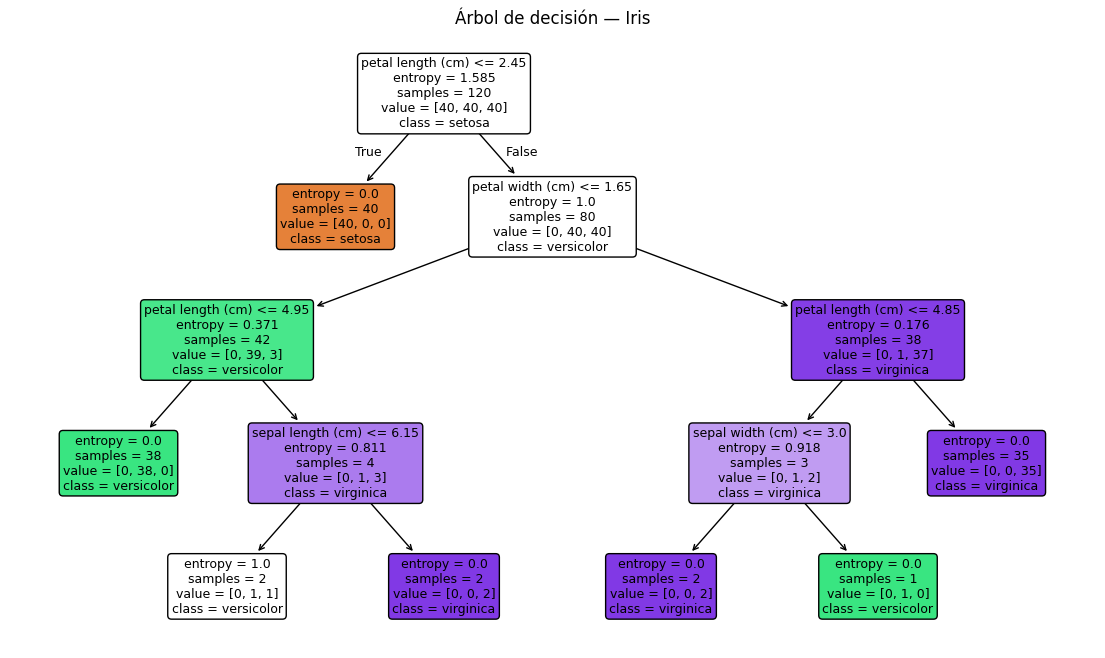

In [7]:
# 6.4 Aplicación con sklearn
from sklearn.tree import DecisionTreeClassifier, plot_tree

data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# El árbol NO requiere escalado
tree = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

print('═══ Árbol de Decisión (criterio: entropía) ═══')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'\n{classification_report(y_test, y_pred)}')

# Visualizar el árbol
plt.figure(figsize=(14, 8))
plot_tree(tree, feature_names=data.feature_names, class_names=data.target_names,
          filled=True, rounded=True, fontsize=9)
plt.title('Árbol de decisión — Iris')
plt.show()

---
<a id='7-random-forest'></a>
# 7️⃣ Random Forest

## 7.1 Fundamentos matemáticos

Random Forest aplica **Bagging (Bootstrap Aggregating)**:

1. **Bootstrapping:** dado un dataset $D$ de tamaño $N$, se crean $B$ muestras aleatorias $D_b$ con reemplazo.
2. **Bosque:** entrena un árbol $T_b$ en cada muestra. En cada split usa solo $m$ características al azar (Feature Bagging).
3. **Predicción:**  
   - Clasificación: $\hat{y} = \text{moda}(T_1(x), \dots, T_B(x))$ (voto mayoritario)  
   - Regresión: $\hat{y} = \frac{1}{B} \sum_b T_b(x)$

## 7.2 Descripción narrativa

**Ensemble de árboles** que reduce la varianza individual de cada árbol gracias a la diversidad del bosque (datos y features aleatorios). "Un árbol puede equivocarse, pero un bosque difícilmente lo hará".

## 7.3 Pseudocódigo (literal)

```
Algoritmo: Random Forest
Entrada: Dataset D, número de árboles B, subconjunto de características m

1. Para b = 1 hasta B:
   - Crear una muestra Bootstrap D_b de los datos originales
   - Entrenar un árbol T_b usando D_b
   - En cada división del árbol, seleccionar solo m características al azar
   - Elegir el mejor corte entre esas m características
2. Para predecir un dato nuevo:
   - Pasar el dato por los B árboles
   - Realizar votación y devolver la clase más frecuente
```

═══ Random Forest ═══
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1       : 0.9655


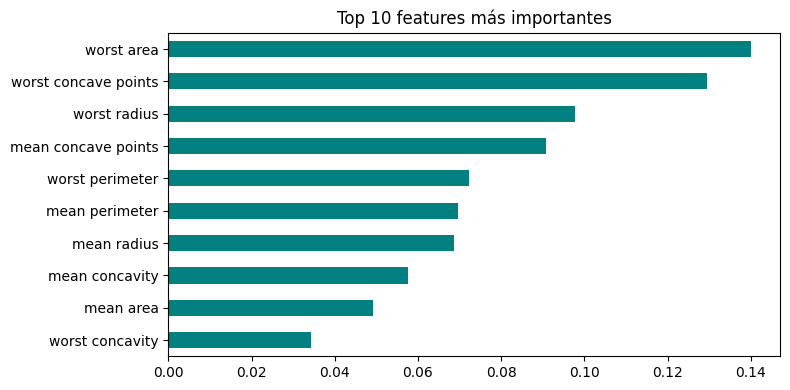

In [8]:
# 7.4 Aplicación
from sklearn.ensemble import RandomForestClassifier

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Random Forest no requiere escalado
rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('═══ Random Forest ═══')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1       : {f1_score(y_test, y_pred):.4f}')

# Importancia de variables (ventaja de RF)
imp = pd.Series(rf.feature_importances_, index=data.feature_names).sort_values()
imp.tail(10).plot(kind='barh', figsize=(8, 4), color='teal')
plt.title('Top 10 features más importantes')
plt.tight_layout()
plt.show()

---
<a id='8-gradient-boosting'></a>
# 8️⃣ Gradient Boosting

## 8.1 Fundamentos matemáticos

**Modelo aditivo:**
$$F_M(x) = \sum_{m=1}^M \gamma_m h_m(x)$$

donde $h_m(x)$ son árboles débiles y $\gamma_m$ es el peso de cada uno.

**Pseudo-residuos** (gradiente negativo):
$$r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F(x) = F_{m-1}(x)}$$

**Actualización:** $F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$ con $\eta$ = learning rate.

## 8.2 Descripción narrativa

**Ensemble secuencial** donde cada árbol nuevo se entrena para **corregir los errores residuales** del anterior. A diferencia de Random Forest (paralelo), aquí los árboles dependen unos de otros. Reduce el **sesgo**.

## 8.3 Pseudocódigo (literal)

```
Algoritmo: Gradient Boosting
Entrada: Dataset D, función de pérdida L, M iteraciones, tasa η

1. Inicializar F_0(x) = arg min_γ Σ L(y_i, γ)
2. Para m = 1 hasta M:
   - Calcular los residuos r_im para cada ejemplo
   - Entrenar un árbol h_m(x) usando los residuos como nuevo target
   - Actualizar el modelo: F_m(x) = F_{m-1}(x) + η * h_m(x)
3. Salida: el modelo final F_M(x)
```

In [9]:
# 8.4 Aplicación
from sklearn.ensemble import GradientBoostingClassifier

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                 max_depth=3, random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

print('═══ Gradient Boosting ═══')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1       : {f1_score(y_test, y_pred):.4f}')
print(f'\nMatriz de confusión:\n{confusion_matrix(y_test, y_pred)}')

═══ Gradient Boosting ═══
Accuracy : 0.9561
Precision: 0.9467
Recall   : 0.9861
F1       : 0.9660

Matriz de confusión:
[[38  4]
 [ 1 71]]


---
<a id='9-xgboost'></a>
# 9️⃣ XGBoost

## 9.1 Fundamentos matemáticos

**Función objetivo regularizada:**
$$Obj(\phi) = \sum_i L(y_i, \hat{y}_i) + \sum_k \Omega(f_k)$$

donde $\Omega(f) = \gamma T + \frac{1}{2} \lambda \|\omega\|^2$ controla la complejidad ($T$ = nº de hojas, $\omega$ = pesos).

**Aproximación de Taylor de 2º orden** usando gradiente $g_i$ y Hessiano $h_i$.

**Ganancia de un split:**
$$Gain = \frac{1}{2}\left[\frac{(\sum g_L)^2}{\sum h_L + \lambda} + \frac{(\sum g_R)^2}{\sum h_R + \lambda} - \frac{(\sum g_L + g_R)^2}{\sum h_L + h_R + \lambda}\right] - \gamma$$

## 9.2 Descripción narrativa

**Implementación optimizada y regularizada** del Gradient Boosting. Características clave: regularización L1/L2, paralelización de búsqueda de splits, manejo nativo de valores nulos. Domina competiciones de Kaggle.

## 9.3 Pseudocódigo (literal)

```
Algoritmo: XGBoost (Nivel de Nodo)
Entrada: Residuos previos, gradientes g_i, hessianos h_i

Para cada posible split:
  1. Calcular Gain (fórmula de arriba)
  2. Elegir el split que maximice el Gain
  3. Si Gain máximo < 0 → poda (prune)
  4. Asignar peso óptimo a la hoja:
     w* = -(Σ g_i) / (Σ h_i + λ)
```

In [10]:
# 9.4 Aplicación con XGBoost (si no está instalado, usa GradientBoostingClassifier de sklearn)
try:
    import xgboost as xgb
    modelo = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                                random_state=RANDOM_STATE, eval_metric='logloss')
    nombre = 'XGBoost'
except ImportError:
    print('⚠️ xgboost no instalado, usando GradientBoosting de sklearn')
    from sklearn.ensemble import GradientBoostingClassifier
    modelo = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                         max_depth=3, random_state=RANDOM_STATE)
    nombre = 'Gradient Boosting (sklearn)'

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print(f'═══ {nombre} ═══')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1       : {f1_score(y_test, y_pred):.4f}')

⚠️ xgboost no instalado, usando GradientBoosting de sklearn


═══ Gradient Boosting (sklearn) ═══
Accuracy : 0.9561
Precision: 0.9467
Recall   : 0.9861
F1       : 0.9660


---
<a id='10-kmeans'></a>
# 🔟 K-means Clustering

## 10.1 Fundamentos matemáticos

**Inercia (suma de cuadrados intra-cluster, WCSS):**
$$J = \sum_{j=1}^K \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

**Centroide:**
$$\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i$$

**Distancia (euclidiana):** $d(x, \mu) = \sqrt{\sum (x_i - \mu_i)^2}$

## 10.2 Descripción narrativa

Algoritmo de **clustering particional, no supervisado**: divide $n$ puntos en $K$ grupos minimizando la varianza intra-cluster. Asume clusters esféricos. **Sensible a escala y outliers** → siempre normalizar.

## 10.3 Pseudocódigo (literal)

```
Algoritmo: K-means Clustering
Entrada: Dataset X, número de clusters K

1. Inicializar K centroides aleatoriamente
2. Repetir hasta convergencia (o máx. iteraciones):
   • Asignación: cada punto x_i va al centroide μ_j más cercano
   • Actualización: μ_j = (1/|C_j|) * Σ_{x_i ∈ C_j} x_i
3. Salida: K centroides + etiquetas de pertenencia
```

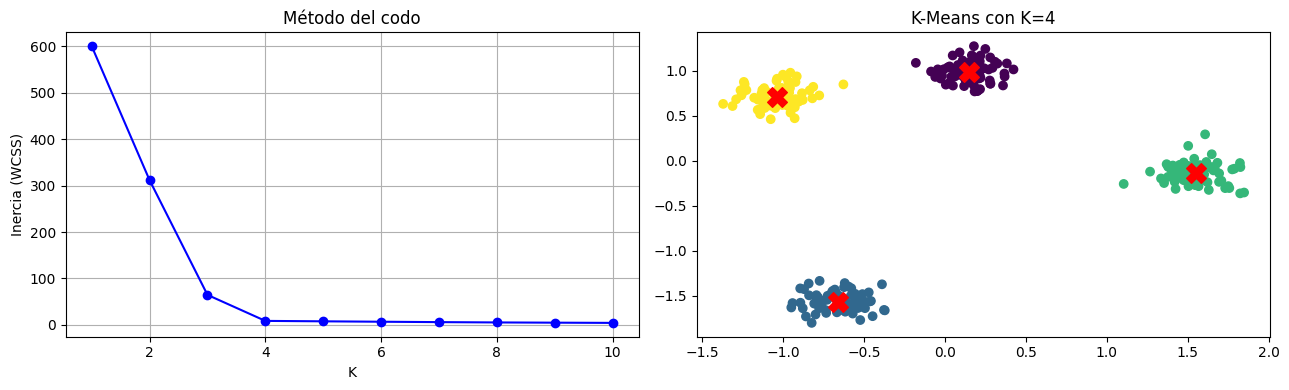

Inercia final: 8.70
Silhouette score: 0.8592


In [11]:
# 10.4 Aplicación
from sklearn.cluster import KMeans

# Generar datos
X, y_real = make_blobs(n_samples=300, centers=4, cluster_std=0.7, random_state=RANDOM_STATE)

# Buena práctica: escalar
X_esc = StandardScaler().fit_transform(X)

# Elegir K con el método del codo
inercias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_esc)
    inercias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(1,11), inercias, 'bo-'); axes[0].set_title('Método del codo')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inercia (WCSS)')
axes[0].grid(True)

# Aplicar K elegido
K = 4
km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
etiquetas = km.fit_predict(X_esc)

axes[1].scatter(X_esc[:,0], X_esc[:,1], c=etiquetas, cmap='viridis')
axes[1].scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], s=200, c='red', marker='X')
axes[1].set_title(f'K-Means con K={K}')
plt.tight_layout(); plt.show()

print(f'Inercia final: {km.inertia_:.2f}')
print(f'Silhouette score: {silhouette_score(X_esc, etiquetas):.4f}')

---
<a id='11-dbscan'></a>
# 1️⃣1️⃣ DBSCAN

## 11.1 Fundamentos matemáticos

Dados parámetros $\varepsilon$ (radio) y $MinPts$:

**Vecindad** $N_\varepsilon(p) = \{q : dist(p,q) \leq \varepsilon\}$.

**Tipos de puntos:**
- **Core point:** $|N_\varepsilon(p)| \geq MinPts$
- **Border point:** no es core pero está en la vecindad de un core
- **Noise:** ni core ni border

Un cluster es el **conjunto máximo de puntos alcanzables por densidad** entre sí.

## 11.2 Descripción narrativa

Clustering **basado en densidad**. **No requiere K** y descubre clusters de **forma arbitraria** (lunas, anillos). Identifica **ruido / outliers**. Sensible a la escala (siempre normalizar).

## 11.3 Pseudocódigo (literal)

```
Algoritmo: DBSCAN
Entrada: Dataset X, ε, MinPts

1. Etiquetar todos los puntos como NO VISITADOS
2. Para cada punto P en X:
   • Si P ya fue visitado, continuar
   • Marcar P como VISITADO
   • Buscar vecinos de P a distancia ε
   • Si |vecinos| < MinPts → P es RUIDO
   • Sino:
       - Crear nuevo cluster C; añadir P
       - Expandir cluster: para cada vecino P', si tiene suficientes vecinos,
         agregarlo y propagar la búsqueda
```

Clusters detectados: 2
Puntos ruido: 0


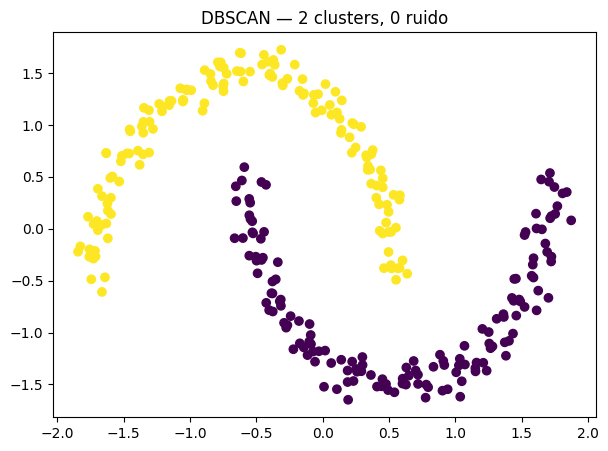

In [12]:
# 11.4 Aplicación con datos en forma de lunas (donde K-means falla)
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=300, noise=0.05, random_state=RANDOM_STATE)
X_esc = StandardScaler().fit_transform(X)

db = DBSCAN(eps=0.3, min_samples=5)
etiquetas = db.fit_predict(X_esc)

n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
n_ruido = list(etiquetas).count(-1)

print(f'Clusters detectados: {n_clusters}')
print(f'Puntos ruido: {n_ruido}')

plt.figure(figsize=(7,5))
plt.scatter(X_esc[:,0], X_esc[:,1], c=etiquetas, cmap='viridis')
plt.title(f'DBSCAN — {n_clusters} clusters, {n_ruido} ruido')
plt.show()

---
<a id='12-hac'></a>
# 1️⃣2️⃣ Hierarchical Agglomerative Clustering (HAC)

## 12.1 Fundamentos matemáticos

Dado $n$ puntos:
1. Calcular **matriz de distancia** inicial.
2. Encontrar el par $(C_i, C_j)$ con distancia mínima según un **criterio de enlace**.
3. Fusionar y actualizar la matriz.
4. Repetir hasta tener un solo cluster.

**Criterios de enlace (linkage):**
- **Single:** distancia mínima entre puntos.
- **Complete:** distancia máxima entre puntos.
- **Average:** promedio de distancias.
- **Ward:** minimiza el aumento de la varianza intra-cluster.

## 12.2 Descripción narrativa

Clustering **jerárquico bottom-up**: cada punto empieza como su propio cluster y se van **fusionando los más cercanos**. Produce un **dendrograma** que permite elegir cualquier número de clusters cortando a la altura deseada.

## 12.3 Pseudocódigo (literal)

```
Algoritmo: Hierarchical Agglomerative Clustering (HAC)
Entrada: Dataset X, métrica de distancia, criterio de enlace

1. Inicializar cada x_i como un cluster C_i
2. Calcular la matriz de distancias D entre todos los clusters
3. Mientras número de clusters > 1:
   • Buscar (C_i, C_j) tales que dist(C_i, C_j) sea mínima
   • Combinar C_i y C_j en C_union
   • Actualizar D usando el criterio de enlace
   • Registrar la fusión y la distancia para el dendrograma
4. Salida: Historia de fusiones (Z-matrix)
```

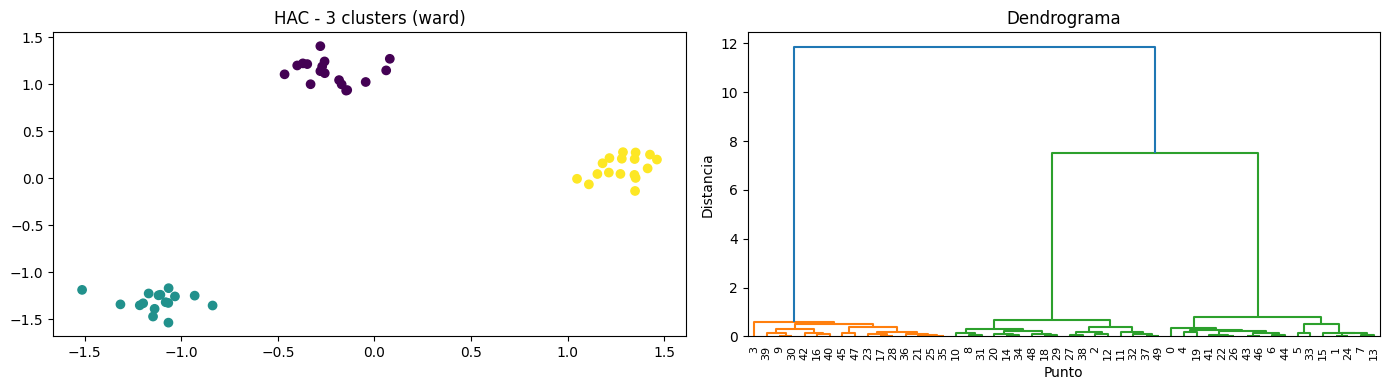

Silhouette: 0.8849


In [13]:
# 12.4 Aplicación
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

X, _ = make_blobs(n_samples=50, centers=3, cluster_std=0.8, random_state=RANDOM_STATE)
X_esc = StandardScaler().fit_transform(X)

# Modelo
hac = AgglomerativeClustering(n_clusters=3, linkage='ward')
etiquetas = hac.fit_predict(X_esc)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Clusters
axes[0].scatter(X_esc[:,0], X_esc[:,1], c=etiquetas, cmap='viridis')
axes[0].set_title('HAC - 3 clusters (ward)')

# Dendrograma
Z = linkage(X_esc, method='ward')
dendrogram(Z, ax=axes[1])
axes[1].set_title('Dendrograma')
axes[1].set_xlabel('Punto')
axes[1].set_ylabel('Distancia')
plt.tight_layout(); plt.show()

print(f'Silhouette: {silhouette_score(X_esc, etiquetas):.4f}')

---
<a id='13-iforest'></a>
# 1️⃣3️⃣ Isolation Forest

## 13.1 Fundamentos matemáticos

Construye un conjunto de **iTrees** (árboles de aislamiento) con divisiones aleatorias.

**Longitud del camino** $h(x)$: número de aristas que recorre $x$ desde la raíz hasta la hoja.

**Factor de normalización:**
$$c(n) = 2H(n-1) - \frac{2(n-1)}{n}$$

donde $H(i) = \ln(i) + 0.5772156649$ (constante de Euler-Mascheroni).

**Anomaly Score:**
$$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$

**Interpretación:**
- $s \to 1$ → anomalía clara
- $s < 0.5$ → punto normal

## 13.2 Descripción narrativa

Algoritmo **no supervisado para detección de anomalías**. Las anomalías son **"pocas y diferentes"**, fáciles de aislar con pocos cortes. Las normales requieren muchos cortes. Muy eficiente: complejidad lineal y baja memoria.

## 13.3 Pseudocódigo (literal)

```
Algoritmo: Isolation Forest (iForest)
Entrada: Dataset X, número de árboles t, tamaño de submuestra ψ

1. Para i = 1 hasta t:
   • Tomar una submuestra X' de tamaño ψ
   • Construir un iTree:
       - Seleccionar característica q al azar
       - Seleccionar punto de corte p al azar entre min y max de q
       - Dividir datos en X_izq y X_der
       - Repetir recursivamente hasta nodo de un solo punto
         o alcanzar el límite de altura
2. Para cada punto nuevo x:
   • Calcular h(x) en cada uno de los t árboles
   • Calcular Anomaly Score s(x, ψ)
```

Total puntos: 220, anomalías detectadas: 22


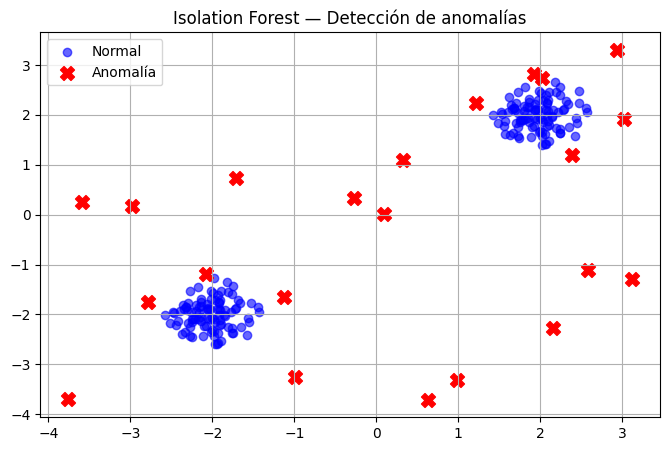

In [14]:
# 13.4 Aplicación
from sklearn.ensemble import IsolationForest

# Datos: la mayoría normales, algunos outliers
rng = np.random.RandomState(RANDOM_STATE)
X_normales = 0.3 * rng.randn(100, 2)
X_outliers = rng.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X_normales + 2, X_normales - 2, X_outliers]

iso = IsolationForest(n_estimators=100, contamination=0.1, random_state=RANDOM_STATE)
y_pred = iso.fit_predict(X)   # 1 normal, -1 anomalía
scores = iso.decision_function(X)

n_anomalias = (y_pred == -1).sum()
print(f'Total puntos: {len(X)}, anomalías detectadas: {n_anomalias}')

plt.figure(figsize=(8,5))
normales = X[y_pred == 1]
anomalias = X[y_pred == -1]
plt.scatter(normales[:,0], normales[:,1], c='blue', label='Normal', alpha=0.6)
plt.scatter(anomalias[:,0], anomalias[:,1], c='red', marker='X', s=100, label='Anomalía')
plt.title('Isolation Forest — Detección de anomalías')
plt.legend(); plt.grid(True); plt.show()

---
# ✅ Buenas prácticas comunes a TODOS los algoritmos

Asegúrate de mencionar/aplicar estas en cualquier algoritmo que te toque:

1. **Semilla fija** (`random_state=42`) para reproducibilidad
2. **División train/test** con `stratify=y` en clasificación
3. **Escalado de variables** con `StandardScaler` para algoritmos basados en distancia (K-NN, SVM, K-Means, DBSCAN)
4. **No fugar datos**: ajustar el scaler **solo con `X_train`**, nunca con todo X
5. **Reportar varias métricas**: Accuracy + Precision + Recall + F1 + Matriz de confusión
6. **Visualizar** cuando aporte: matriz de confusión, dendrograma, frontera de decisión
7. **Comentarios** explicativos en el código
8. **Conclusión final** interpretando los resultados

## Tabla de cuándo escalar

| Algoritmo | ¿Escalar? |
|-----------|:---------:|
| Regresión Lineal/Logística | ✅ Recomendado |
| SVM | ✅ Crítico |
| K-NN | ✅ Crítico |
| Naive Bayes | ❌ No es necesario |
| Árbol de Decisión | ❌ No |
| Random Forest | ❌ No |
| Gradient Boosting / XGBoost | ❌ No |
| K-Means | ✅ Crítico |
| DBSCAN | ✅ Crítico |
| HAC | ✅ Recomendado |
| Isolation Forest | ❌ No es necesario |

**¡Mucha suerte! 🍀**